# Assignment 7

**Stats M148 FingerHut Project**  
Isaiah C. Mireles, Charlie Kopp, Joel Yoon

This notebook contains the full assignment workflow. There is no separate analysis `.py` file required; all helper functions, model fitting, and plotting code are included below.

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import Image, display
from sklearn.ensemble import RandomForestClassifier

def find_repo_dir():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for candidate in candidates:
        if (candidate / "joel" / "dat_train1.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find joel/dat_train1.csv from the current working directory.")

REPO_DIR = find_repo_dir()
JOEL_DIR = REPO_DIR / "joel"
ASSIGNMENT_DIR = JOEL_DIR / "assignment7"
TRAIN_PATH = JOEL_DIR / "dat_train1.csv"
ASSIGNMENT_DIR.mkdir(parents=True, exist_ok=True)

MONTHLY_ORDERS_PATH = ASSIGNMENT_DIR / "assignment7_monthly_orders.csv"
FORECAST_PATH = ASSIGNMENT_DIR / "assignment7_forecast_2024.csv"
COEFFICIENT_PATH = ASSIGNMENT_DIR / "assignment7_model_coefficients.csv"
ANNUAL_FORECAST_PATH = ASSIGNMENT_DIR / "assignment7_annual_forecast.csv"
FORECAST_PLOT_PATH = ASSIGNMENT_DIR / "assignment7_orders_forecast.png"
PROBABILITY_TIMELINE_PATH = ASSIGNMENT_DIR / "assignment7_probability_over_time.csv"
PROBABILITY_PLOT_PATH = ASSIGNMENT_DIR / "assignment7_probability_over_time.png"
PROBABILITY_ZOOM_PLOT_PATH = ASSIGNMENT_DIR / "assignment7_probability_over_time_zoom.png"
DROPOUT_PLOT_PATH = ASSIGNMENT_DIR / "assignment7_dropout_events.png"
DROPOUT_SUMMARY_PATH = ASSIGNMENT_DIR / "assignment7_dropout_summary.csv"

SELECTED_EVENTS = [
    "browse_products",
    "view_cart",
    "add_to_cart",
    "begin_checkout",
    "place_order_web",
    "place_order_phone",
    "place_downpayment",
    "application_web_view",
    "application_web_submit",
    "application_web_approved",
    "promotion_created",
    "campaignemail_clicked",
    "campaign_click",
]


def aggregate_monthly_orders(chunksize=1_000_000):
    """Count order_shipped events per month from the full training CSV."""
    if MONTHLY_ORDERS_PATH.exists():
        return pd.read_csv(MONTHLY_ORDERS_PATH, parse_dates=["month"])

    month_counts = {}
    for i, chunk in enumerate(
        pd.read_csv(TRAIN_PATH, usecols=["event_name", "event_timestamp"], chunksize=chunksize),
        start=1,
    ):
        shipped_months = chunk.loc[chunk["event_name"].eq("order_shipped"), "event_timestamp"].str.slice(0, 7)
        for month, count in shipped_months.value_counts().items():
            month_counts[month] = month_counts.get(month, 0) + int(count)
        if i % 10 == 0:
            print(f"processed {i * chunksize:,} rows")

    monthly = (
        pd.Series(month_counts, name="orders_shipped")
        .rename_axis("month")
        .reset_index()
        .sort_values("month")
    )
    monthly["month"] = pd.to_datetime(monthly["month"] + "-01")
    full_months = pd.date_range(monthly["month"].min(), monthly["month"].max(), freq="MS")
    monthly = (
        monthly.set_index("month")
        .reindex(full_months, fill_value=0)
        .rename_axis("month")
        .reset_index()
    )
    monthly.to_csv(MONTHLY_ORDERS_PATH, index=False)
    return monthly


def seasonal_design(months, start_month):
    months = pd.Series(pd.to_datetime(months))
    month_numbers = months.dt.month.to_numpy()
    t = ((months.dt.year - start_month.year) * 12 + (months.dt.month - start_month.month)).to_numpy()
    angle = 2 * np.pi * (month_numbers - 1) / 12
    return pd.DataFrame(
        {
            "intercept": 1.0,
            "trend_month": t,
            "sin_annual": np.sin(angle),
            "cos_annual": np.cos(angle),
            "sin_semiannual": np.sin(2 * angle),
            "cos_semiannual": np.cos(2 * angle),
        }
    )


def fit_and_plot_forecast(monthly):
    """Fit a seasonal Poisson regression and forecast 2024 monthly orders."""
    train = monthly[(monthly["month"] >= "2021-02-01") & (monthly["month"] < "2023-01-01")].copy()
    start_month = train["month"].min()
    x_train = seasonal_design(train["month"], start_month)
    model = sm.GLM(train["orders_shipped"].to_numpy(), x_train, family=sm.families.Poisson())
    result = model.fit(cov_type="HC0")

    coefficients = pd.DataFrame(
        {
            "term": result.params.index,
            "estimate": result.params.values,
            "conf_low": result.conf_int()[0].values,
            "conf_high": result.conf_int()[1].values,
            "p_value": result.pvalues.values,
        }
    )
    coefficients["multiplicative_effect"] = np.exp(coefficients["estimate"])
    coefficients.to_csv(COEFFICIENT_PATH, index=False)

    future_months = pd.date_range("2024-01-01", "2024-12-01", freq="MS")
    x_future = seasonal_design(future_months, start_month)
    pred = result.get_prediction(x_future).summary_frame(alpha=0.05)
    forecast = pd.DataFrame(
        {
            "month": future_months,
            "predicted_mean": pred["mean"].to_numpy(),
            "ci_lower": pred["mean_ci_lower"].to_numpy(),
            "ci_upper": pred["mean_ci_upper"].to_numpy(),
        }
    )
    forecast[["predicted_mean", "ci_lower", "ci_upper"]] = forecast[
        ["predicted_mean", "ci_lower", "ci_upper"]
    ].clip(lower=0)
    forecast.to_csv(FORECAST_PATH, index=False)

    rng = np.random.default_rng(148)
    draws = rng.multivariate_normal(result.params.to_numpy(), result.cov_params().to_numpy(), size=20_000, check_valid="ignore")
    simulated_total = np.exp(x_future.to_numpy() @ draws.T).sum(axis=0)
    annual = pd.DataFrame(
        {
            "year": [2024],
            "predicted_mean": [forecast["predicted_mean"].sum()],
            "ci_lower": [np.quantile(simulated_total, 0.025)],
            "ci_upper": [np.quantile(simulated_total, 0.975)],
        }
    )
    annual.to_csv(ANNUAL_FORECAST_PATH, index=False)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.plot(monthly["month"], monthly["orders_shipped"], marker="o", linewidth=1.5,
            label="Observed monthly shipments", color="#253858")
    ax.axvspan(pd.Timestamp("2021-02-01"), pd.Timestamp("2022-12-01"), color="#dfe7ef", alpha=0.35)
    ax.plot(forecast["month"], forecast["predicted_mean"], marker="o", linewidth=2,
            label="2024 forecast mean", color="#c84a31")
    ax.fill_between(forecast["month"], forecast["ci_lower"], forecast["ci_upper"],
                    color="#c84a31", alpha=0.18, label="95% confidence interval")
    ax.set_title("Monthly Orders Shipped and 2024 Forecast")
    ax.set_xlabel("Month")
    ax.set_ylabel("Orders shipped")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(FORECAST_PLOT_PATH, dpi=180)
    plt.close(fig)
    return forecast, coefficients, annual


def build_features(events):
    """Create journey-level features from events visible at snapshot time."""
    events = events.sort_values(["id", "event_timestamp"]).copy()
    grouped = events.groupby("id")
    features = grouped.agg(
        n_events=("event_name", "size"),
        n_unique_events=("event_name", "nunique"),
        first_event_time=("event_timestamp", "min"),
        last_event_time=("event_timestamp", "max"),
    )
    features["journey_duration_days"] = (
        features["last_event_time"] - features["first_event_time"]
    ).dt.total_seconds() / 86400
    event_counts = (
        events[events["event_name"].isin(SELECTED_EVENTS)]
        .groupby(["id", "event_name"])
        .size()
        .unstack(fill_value=0)
    )
    event_counts = event_counts.reindex(columns=SELECTED_EVENTS, fill_value=0).add_prefix("n_")
    last_events = grouped.tail(1).set_index("id")["event_name"]
    for event_name in SELECTED_EVENTS:
        features[f"last_is_{event_name}"] = (last_events == event_name).astype(int)
    return features.join(event_counts, how="left").fillna(0).drop(columns=["first_event_time", "last_event_time"])


def make_training_snapshots(df, max_training_rows=30_000):
    """Create labeled point-in-time training rows from completed historical journeys."""
    cutoff_date = df["event_timestamp"].max() - pd.Timedelta(days=60)
    first_ship = (
        df.loc[df["event_name"].eq("order_shipped")]
        .groupby("id")["event_timestamp"]
        .min()
        .rename("first_ship_time")
    )
    last_event_time = df.groupby("id")["event_timestamp"].max().rename("last_event_time")
    status = pd.concat([first_ship, last_event_time], axis=1)
    positive_ids = status.index[status["first_ship_time"].notna()]
    negative_ids = status.index[status["first_ship_time"].isna() & (status["last_event_time"] < cutoff_date)]
    labels = pd.concat([
        pd.Series(1, index=positive_ids, name="will_ship"),
        pd.Series(0, index=negative_ids, name="will_ship"),
    ])
    if len(labels) > max_training_rows:
        per_class = min(max_training_rows // 2, labels.value_counts().min())
        labels = labels.groupby(labels).sample(n=per_class, random_state=148).sort_index()

    selected = df[df["id"].isin(labels.index)].merge(first_ship, left_on="id", right_index=True, how="left")
    snapshot_events = selected[
        selected["first_ship_time"].isna()
        | (selected["event_timestamp"] < selected["first_ship_time"])
    ].drop(columns=["first_ship_time"])
    features = build_features(snapshot_events)
    return features, labels.reindex(features.index), cutoff_date


def load_sample(sample_rows=750_000):
    df = pd.read_csv(
        TRAIN_PATH,
        usecols=["id", "event_name", "event_timestamp"],
        nrows=sample_rows,
        parse_dates=["event_timestamp"],
    )
    df = df.drop_duplicates(subset=["id", "event_name", "event_timestamp"]).copy()
    df["event_timestamp"] = pd.to_datetime(df["event_timestamp"], utc=True)
    return df.sort_values(["id", "event_timestamp"])


def timeline_features(events, columns):
    events = events.sort_values("event_timestamp").reset_index(drop=True)
    journey_id = events.loc[0, "id"]
    first_time = events.loc[0, "event_timestamp"]
    counts = {event: 0 for event in SELECTED_EVENTS}
    unique_events = set()
    rows = []
    for i, row in events.iterrows():
        event = row["event_name"]
        unique_events.add(event)
        if event in counts:
            counts[event] += 1
        feature_row = {
            "n_events": i + 1,
            "n_unique_events": len(unique_events),
            "journey_duration_days": (row["event_timestamp"] - first_time).total_seconds() / 86400,
        }
        for selected in SELECTED_EVENTS:
            feature_row[f"last_is_{selected}"] = int(event == selected)
            feature_row[f"n_{selected}"] = counts[selected]
        rows.append(feature_row)
    return pd.DataFrame(rows, index=pd.Index([journey_id] * len(rows), name="id")).reindex(
        columns=columns, fill_value=0
    ).fillna(0)


def event_style(event):
    if event == "promotion_created":
        return "1: Promo Created", "^", "#8d3fb6", 72
    if event == "browse_products":
        return "4: Browse", "o", "#607d73", 54
    if event == "view_cart":
        return "5: View Cart", "s", "#e56a19", 60
    return "Other Event", "h", "#171717", 50


def plot_probability_timeline(events, probs, journey_id, outcome, out_path, zoom_days=None):
    events = events.sort_values("event_timestamp").reset_index(drop=True).copy()
    start = events["event_timestamp"].iloc[0]
    end = events["event_timestamp"].iloc[-1]
    x = (events["event_timestamp"] - start).dt.total_seconds() / 86400
    duration = (end - start).total_seconds() / 86400

    fig, ax = plt.subplots(figsize=(16, 8))
    ax.step(x, probs, where="post", color="#aab4bf", linewidth=1.7, label="Model Prediction", zorder=1)
    for label in ["1: Promo Created", "4: Browse", "5: View Cart", "Other Event"]:
        mask = []
        marker = color = size = None
        for event in events["event_name"]:
            event_label, event_marker, event_color, event_size = event_style(event)
            mask.append(event_label == label)
            if event_label == label:
                marker, color, size = event_marker, event_color, event_size
        mask = np.array(mask)
        if mask.any():
            ax.scatter(x[mask], np.array(probs)[mask], marker=marker, s=size, color=color,
                       edgecolor="white", linewidth=0.7, label=label, zorder=3)

    ax.axhline(1, color="black", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Journey Probability Timeline\nID: {journey_id} | Outcome: {outcome}", fontsize=16, pad=16)
    ax.set_xlabel("Time since Start (Days)", fontsize=12)
    ax.set_ylabel("Probability of Success", fontsize=12)
    ax.grid(True, color="#c7c7c7", linewidth=1, alpha=0.85)
    if zoom_days is None:
        ax.set_xlim(-max(1, duration * 0.05), duration * 1.05)
        ax.set_ylim(-0.05, 1.05)
    else:
        ax.set_xlim(-1, zoom_days)
        ax.set_ylim(-0.05, max(0.28, min(0.62, np.nanmax(probs) + 0.08)))

    days = int(duration)
    hours = int(round((duration - days) * 24))
    info = (
        f"Start: {start.strftime('%Y-%m-%d %H:%M')}\n"
        f"End:   {end.strftime('%Y-%m-%d %H:%M')}\n"
        f"Events: {len(events)}\n"
        f"Duration: {days} days, {hours:02d}:00"
    )
    ax.text(0.02, 0.05, info, transform=ax.transAxes, fontsize=9, ha="left", va="bottom",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))
    ax.legend(title="Legend", loc="upper left", bbox_to_anchor=(1.005, 1.0), frameon=True, shadow=True)
    fig.tight_layout(rect=[0, 0, 0.88, 1])
    fig.savefig(out_path, dpi=150)
    plt.close(fig)


def make_probability_timeline(sample_rows=750_000):
    df = load_sample(sample_rows)
    x_train, y_train, cutoff_date = make_training_snapshots(df, max_training_rows=30_000)
    rf = RandomForestClassifier(
        n_estimators=250,
        min_samples_leaf=8,
        max_features="sqrt",
        n_jobs=-1,
        oob_score=True,
        random_state=148,
    )
    rf.fit(x_train, y_train)

    summary = df.groupby("id").agg(
        n=("event_name", "size"),
        first=("event_timestamp", "first"),
        last=("event_timestamp", "last"),
        shipped=("event_name", lambda s: bool((s == "order_shipped").any())),
    )
    summary["duration_days"] = (summary["last"] - summary["first"]).dt.total_seconds() / 86400
    failures = summary[(~summary["shipped"]) & (summary["last"] < cutoff_date)].copy()
    candidates = failures[(failures["n"].between(300, 450)) & (failures["duration_days"].between(200, 330))].copy()
    if candidates.empty:
        candidates = failures.sort_values("n", ascending=False).head(20).copy()
    candidates["score"] = (candidates["n"] - 388).abs() + 0.5 * (candidates["duration_days"] - 253).abs()
    journey_id = candidates.sort_values("score").index[0]

    events = df[df["id"].eq(journey_id)].sort_values("event_timestamp").copy()
    features = timeline_features(events, x_train.columns)
    probs = rf.predict_proba(features)[:, 1]

    timeline = events[["id", "event_timestamp", "event_name"]].copy().reset_index(drop=True)
    timeline.insert(0, "event_number", np.arange(1, len(timeline) + 1))
    timeline["time_since_start_days"] = (
        timeline["event_timestamp"] - timeline["event_timestamp"].iloc[0]
    ).dt.total_seconds() / 86400
    timeline["predicted_probability"] = probs
    timeline["probability_delta"] = timeline["predicted_probability"].diff().fillna(timeline["predicted_probability"])
    timeline.to_csv(PROBABILITY_TIMELINE_PATH, index=False)

    plot_probability_timeline(events, probs, journey_id, "Failure", PROBABILITY_PLOT_PATH)
    plot_probability_timeline(events, probs, journey_id, "Failure", PROBABILITY_ZOOM_PLOT_PATH, zoom_days=20)
    return timeline, rf.oob_score_, journey_id, df


def make_dropout_plot(df):
    summary = (
        df.sort_values(["id", "event_timestamp"])
        .groupby("id")
        .agg(
            first_event_time=("event_timestamp", "first"),
            last_event_time=("event_timestamp", "last"),
            last_event_name=("event_name", "last"),
            n_events=("event_name", "size"),
            shipped=("event_name", lambda s: int((s == "order_shipped").any())),
        )
    )
    summary["duration_days"] = (summary["last_event_time"] - summary["first_event_time"]).dt.total_seconds() / 86400
    non_shipped = summary[summary["shipped"].eq(0)].copy()
    terminal_counts = non_shipped["last_event_name"].value_counts().head(12)
    dropout = terminal_counts.rename_axis("last_event_name").reset_index(name="journeys")
    dropout["sample_non_shipped_median_duration_days"] = non_shipped["duration_days"].median()
    dropout["sample_non_shipped_median_events"] = non_shipped["n_events"].median()
    dropout.to_csv(DROPOUT_SUMMARY_PATH, index=False)

    fig, ax = plt.subplots(figsize=(9, 5.5))
    terminal_counts.sort_values().plot(kind="barh", ax=ax, color="#476f95")
    ax.set_title("Most Common Last Events for Non-Shipped Journeys in Sample")
    ax.set_xlabel("Number of journeys")
    ax.set_ylabel("Last observed event")
    ax.grid(axis="x", alpha=0.2)
    fig.tight_layout()
    fig.savefig(DROPOUT_PLOT_PATH, dpi=180)
    plt.close(fig)
    return dropout

print("Assignment directory:", ASSIGNMENT_DIR)

Assignment directory: /Users/joelyoon/Documents/git_repo/m148-project/joel/assignment7


## Task 1 - Time Series of Number of Orders Shipped

We kept the monthly aggregation from the previous time-series work. Daily aggregation has a weekend issue because the warehouse is mostly closed on weekends but the data still contains some low weekend shipment counts. Monthly aggregation smooths out that operational artifact and gives a cleaner series for a 2024 forecast. As before, we excluded the incomplete early period and the partial final month; the model was fit on February 2021 through December 2022.

For this assignment, we used a seasonal Poisson regression with a log link:

$$
\log(E[y_t]) =
\beta_0 + \beta_1 t
+ \beta_2 \sin(2\pi m_t / 12)
+ \beta_3 \cos(2\pi m_t / 12)
+ \beta_4 \sin(4\pi m_t / 12)
+ \beta_5 \cos(4\pi m_t / 12).
$$

Here, $y_t$ is the number of orders shipped in month $t$, $t$ is a linear month index, and $m_t$ is the month of year. This keeps the model interpretable: the trend term captures the overall direction of monthly shipments, while the annual and semiannual Fourier terms capture seasonality.

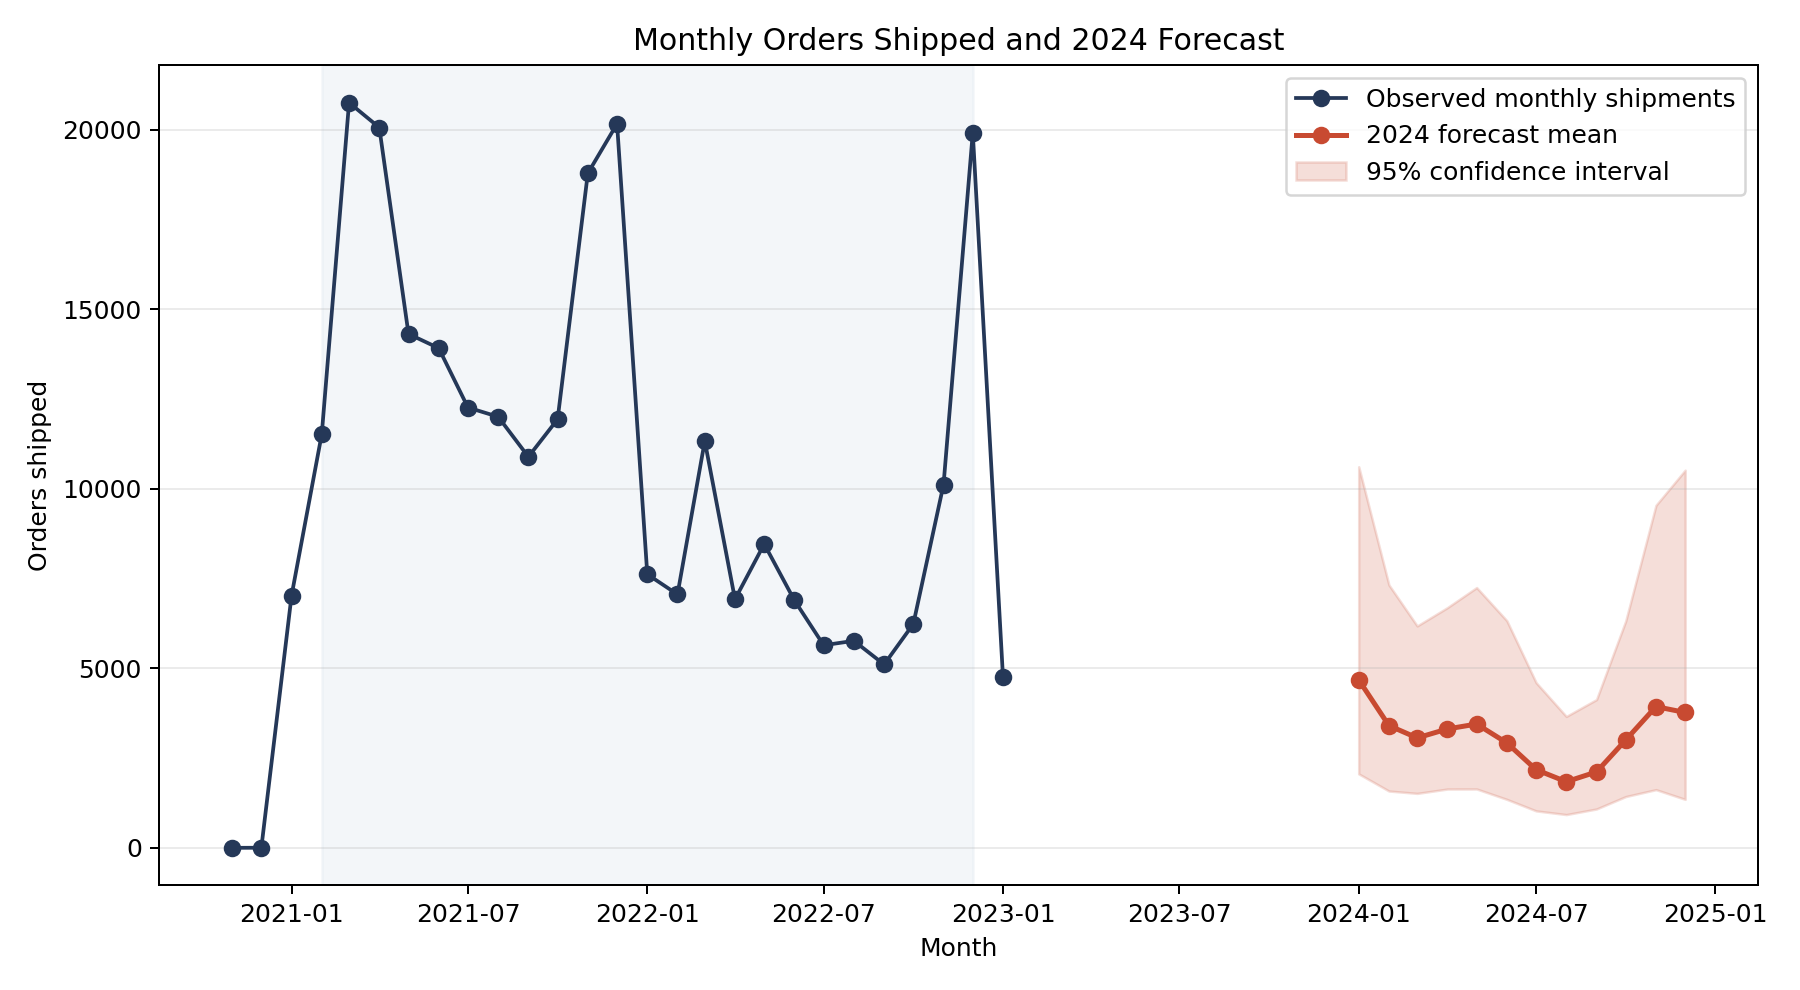

### Coefficients

| Term           | Estimate | 95% CI           | Multiplicative effect |
| -------------- | -------- | ---------------- | --------------------- |
| intercept      | 9.794    | [9.577, 10.011]  | 17921.279             |
| trend_month    | -0.044   | [-0.067, -0.021] | 0.957                 |
| sin_annual     | -0.083   | [-0.211, 0.045]  | 0.920                 |
| cos_annual     | 0.251    | [0.070, 0.432]   | 1.285                 |
| sin_semiannual | -0.264   | [-0.399, -0.129] | 0.768                 |
| cos_semiannual | -0.060   | [-0.232, 0.112]  | 0.942                 |

The trend coefficient is negative: after adjusting for seasonality, each additional month is associated with multiplying the expected shipment count by about 0.957, or about a 4.3% decrease per month. This should be interpreted cautiously because the original data is a project sample, not necessarily a complete company-wide shipment series. The annual and semiannual terms show that seasonality matters, with stronger expected shipment counts around the beginning/end of the year and weaker counts around mid-year.

### Forecast

The model predicts about **37,681** total orders shipped in 2024, with an approximate 95% confidence interval of **17,753 to 81,608**.

| Month    | Predicted mean | 95% CI lower | 95% CI upper |
| -------- | -------------- | ------------ | ------------ |
| Jan 2024 | 4,679          | 2,062        | 10,616       |
| Feb 2024 | 3,406          | 1,584        | 7,324        |
| Mar 2024 | 3,063          | 1,518        | 6,181        |
| Apr 2024 | 3,312          | 1,639        | 6,692        |
| May 2024 | 3,449          | 1,641        | 7,251        |
| Jun 2024 | 2,924          | 1,351        | 6,327        |
| Jul 2024 | 2,178          | 1,031        | 4,603        |
| Aug 2024 | 1,843          | 927          | 3,661        |
| Sep 2024 | 2,116          | 1,083        | 4,132        |
| Oct 2024 | 3,006          | 1,429        | 6,322        |
| Nov 2024 | 3,934          | 1,622        | 9,541        |
| Dec 2024 | 3,771          | 1,352        | 10,521       |

Useful additional predictors would include promotion dates, marketing campaign volume, journey starts, checkout starts, downpayment activity, and broader calendar effects. We did not include those here because the goal was a clean time-series forecast of shipped orders.

processed 10,000,000 rows
processed 20,000,000 rows
processed 30,000,000 rows
processed 40,000,000 rows
processed 50,000,000 rows


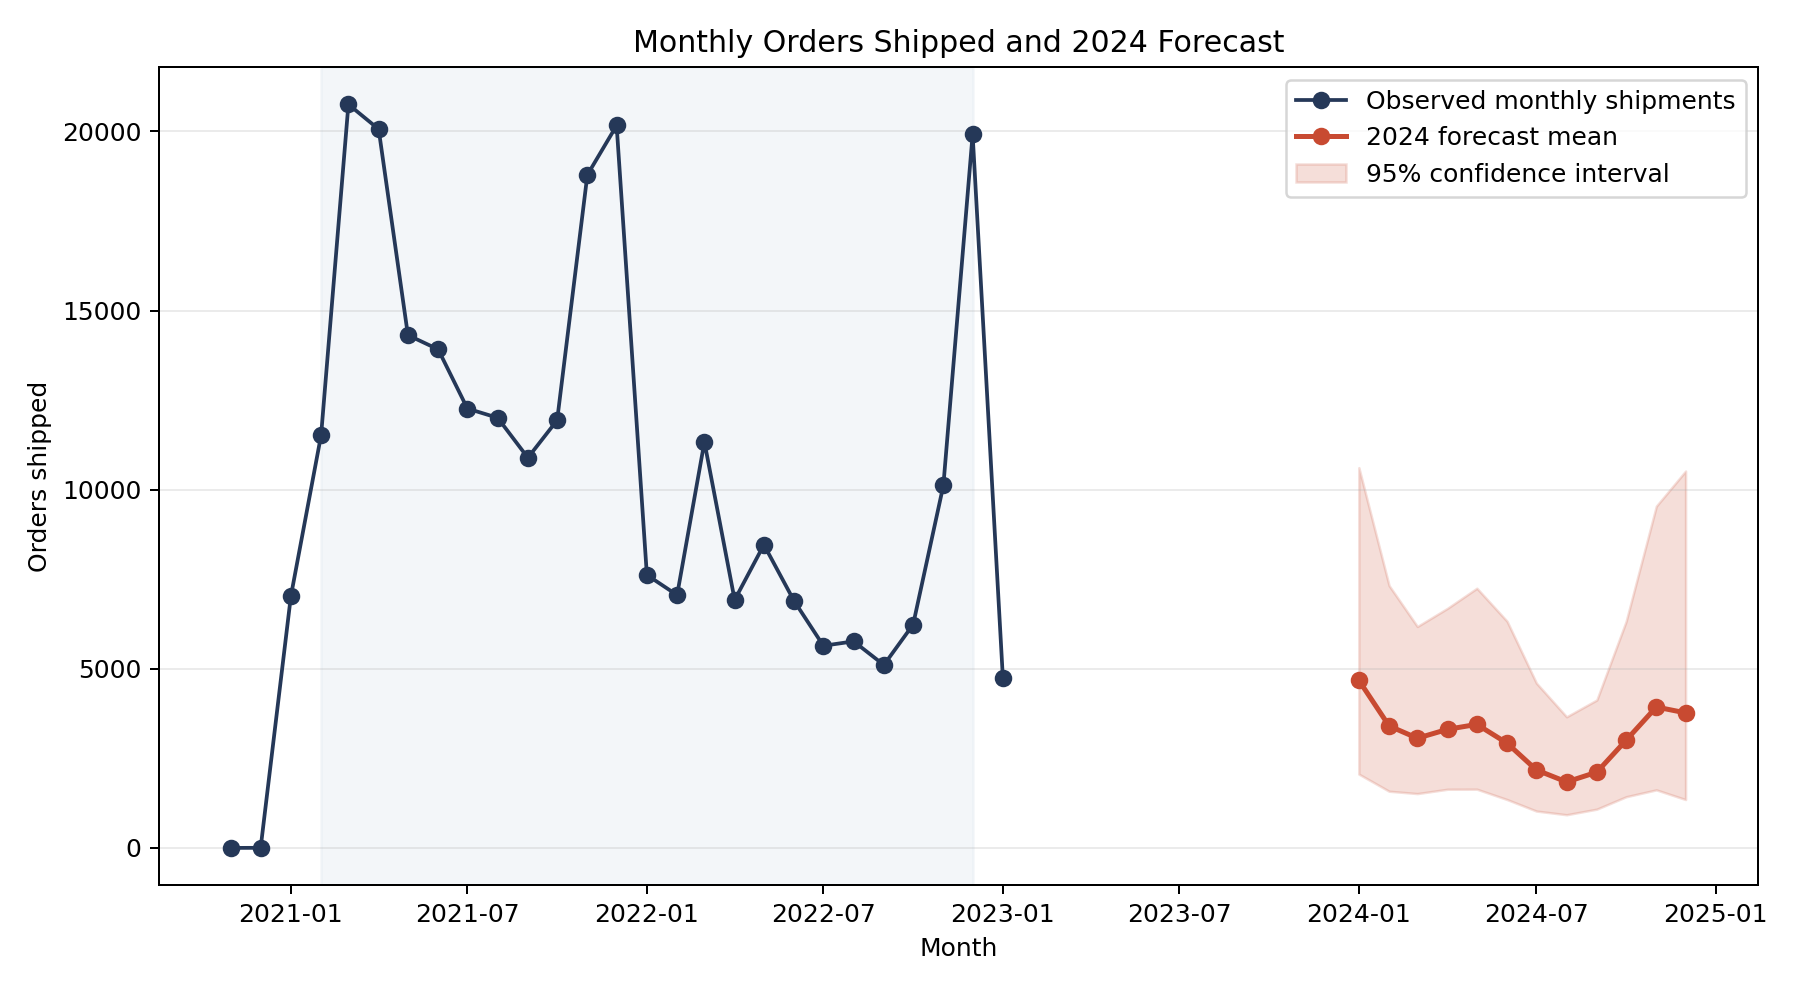

,term,estimate,95% CI,multiplicative_effect
0,intercept,9.794,"[9.577, 10.011]",17921.279
1,trend_month,-0.044,"[-0.067, -0.021]",0.957
2,sin_annual,-0.083,"[-0.211, 0.045]",0.920
3,cos_annual,0.251,"[0.070, 0.432]",1.285
4,sin_semiannual,-0.264,"[-0.399, -0.129]",0.768
5,cos_semiannual,-0.060,"[-0.232, 0.112]",0.942


In [2]:
monthly_orders = aggregate_monthly_orders()
forecast_2024, coefficients, annual_forecast = fit_and_plot_forecast(monthly_orders)

display(Image(filename=str(FORECAST_PLOT_PATH)))

coef_display = coefficients.copy()
coef_display["estimate"] = coef_display["estimate"].map(lambda x: f"{x:.3f}")
coef_display["95% CI"] = coefficients.apply(lambda r: f"[{r['conf_low']:.3f}, {r['conf_high']:.3f}]", axis=1)
coef_display["multiplicative_effect"] = coef_display["multiplicative_effect"].map(lambda x: f"{x:.3f}")
coef_display[["term", "estimate", "95% CI", "multiplicative_effect"]]

In [3]:
forecast_display = forecast_2024.copy()
forecast_display["Month"] = forecast_display["month"].dt.strftime("%b %Y")
for col in ["predicted_mean", "ci_lower", "ci_upper"]:
    forecast_display[col] = forecast_display[col].round().astype(int).map(lambda x: f"{x:,}")
forecast_display[["Month", "predicted_mean", "ci_lower", "ci_upper"]]

,Month,predicted_mean,ci_lower,ci_upper
0,Jan 2024,"4,679","2,062","10,616"
1,Feb 2024,"3,406","1,584","7,324"
2,Mar 2024,"3,063","1,518","6,181"
3,Apr 2024,"3,312","1,639","6,692"
4,May 2024,"3,449","1,641","7,251"
5,Jun 2024,"2,924","1,351","6,327"
6,Jul 2024,"2,178","1,031","4,603"
7,Aug 2024,"1,843",927,"3,661"
8,Sep 2024,"2,116","1,083","4,132"
9,Oct 2024,"3,006","1,429","6,322"


## Task 2 - Improve Predictive Performance

For the incomplete-journey prediction model, the biggest improvement is to make the training examples look more like real incomplete journeys. In the earlier model, a journey often contributed one simplified snapshot. A better strategy is to sample multiple point-in-time snapshots from completed journeys, then label each snapshot by whether the journey eventually reaches `order_shipped` or goes inactive for at least 60 days.

The sampling should be calibrated to the test set. We should sample cut points across the journey instead of mostly near the final outcome, and we should match the distribution of journey age, number of actions, and time since last action seen in the open journeys. This helps avoid leakage and keeps the model from learning only "almost shipped" examples.

Additional predictor variables worth adding:

- Recency features: time since last action, time since first action, time since last checkout/order/downpayment event.
- Frequency features: total actions, actions in the last 1/7/30 days, and average time between actions.
- Funnel-stage features: deepest stage reached, last stage, number of transitions between stages.
- Sequence features: recent action n-grams, repeated failed application attempts, repeated cart-checkout loops.
- Promotion features: number of promotions received/clicked, campaign clicks before and after cart or application events.
- Calendar features: month, week of year, holidays, and possibly the shipment forecast level for the current period.

For modeling, I would keep the random forest baseline but compare it against gradient boosting and a regularized logistic model. Since the Kaggle scoring emphasizes probabilities, calibration matters: after fitting the classifier, we should check Brier score, reliability curves, and possibly use isotonic or Platt calibration on a validation set split by journey id.

## Task 3 - Predicted Probability Over Time

Using the reference plots as a template, the plot below shows one failure journey's model probability over time. The x-axis is time since the start of the journey in days, the gray step line is the random forest prediction after each observed action, and the markers show the actual user/company actions. All 396 observed actions for this journey are included.

The event markers use the same style as the reference: `promotion_created` is shown as a purple triangle, `browse_products` as a green/gray circle, `view_cart` as an orange square, and all other events as black hexagons. The random forest was trained on a 750,000-row sample with the same point-in-time training strategy used in the previous assignments. Its OOB accuracy on that sample was 0.978.

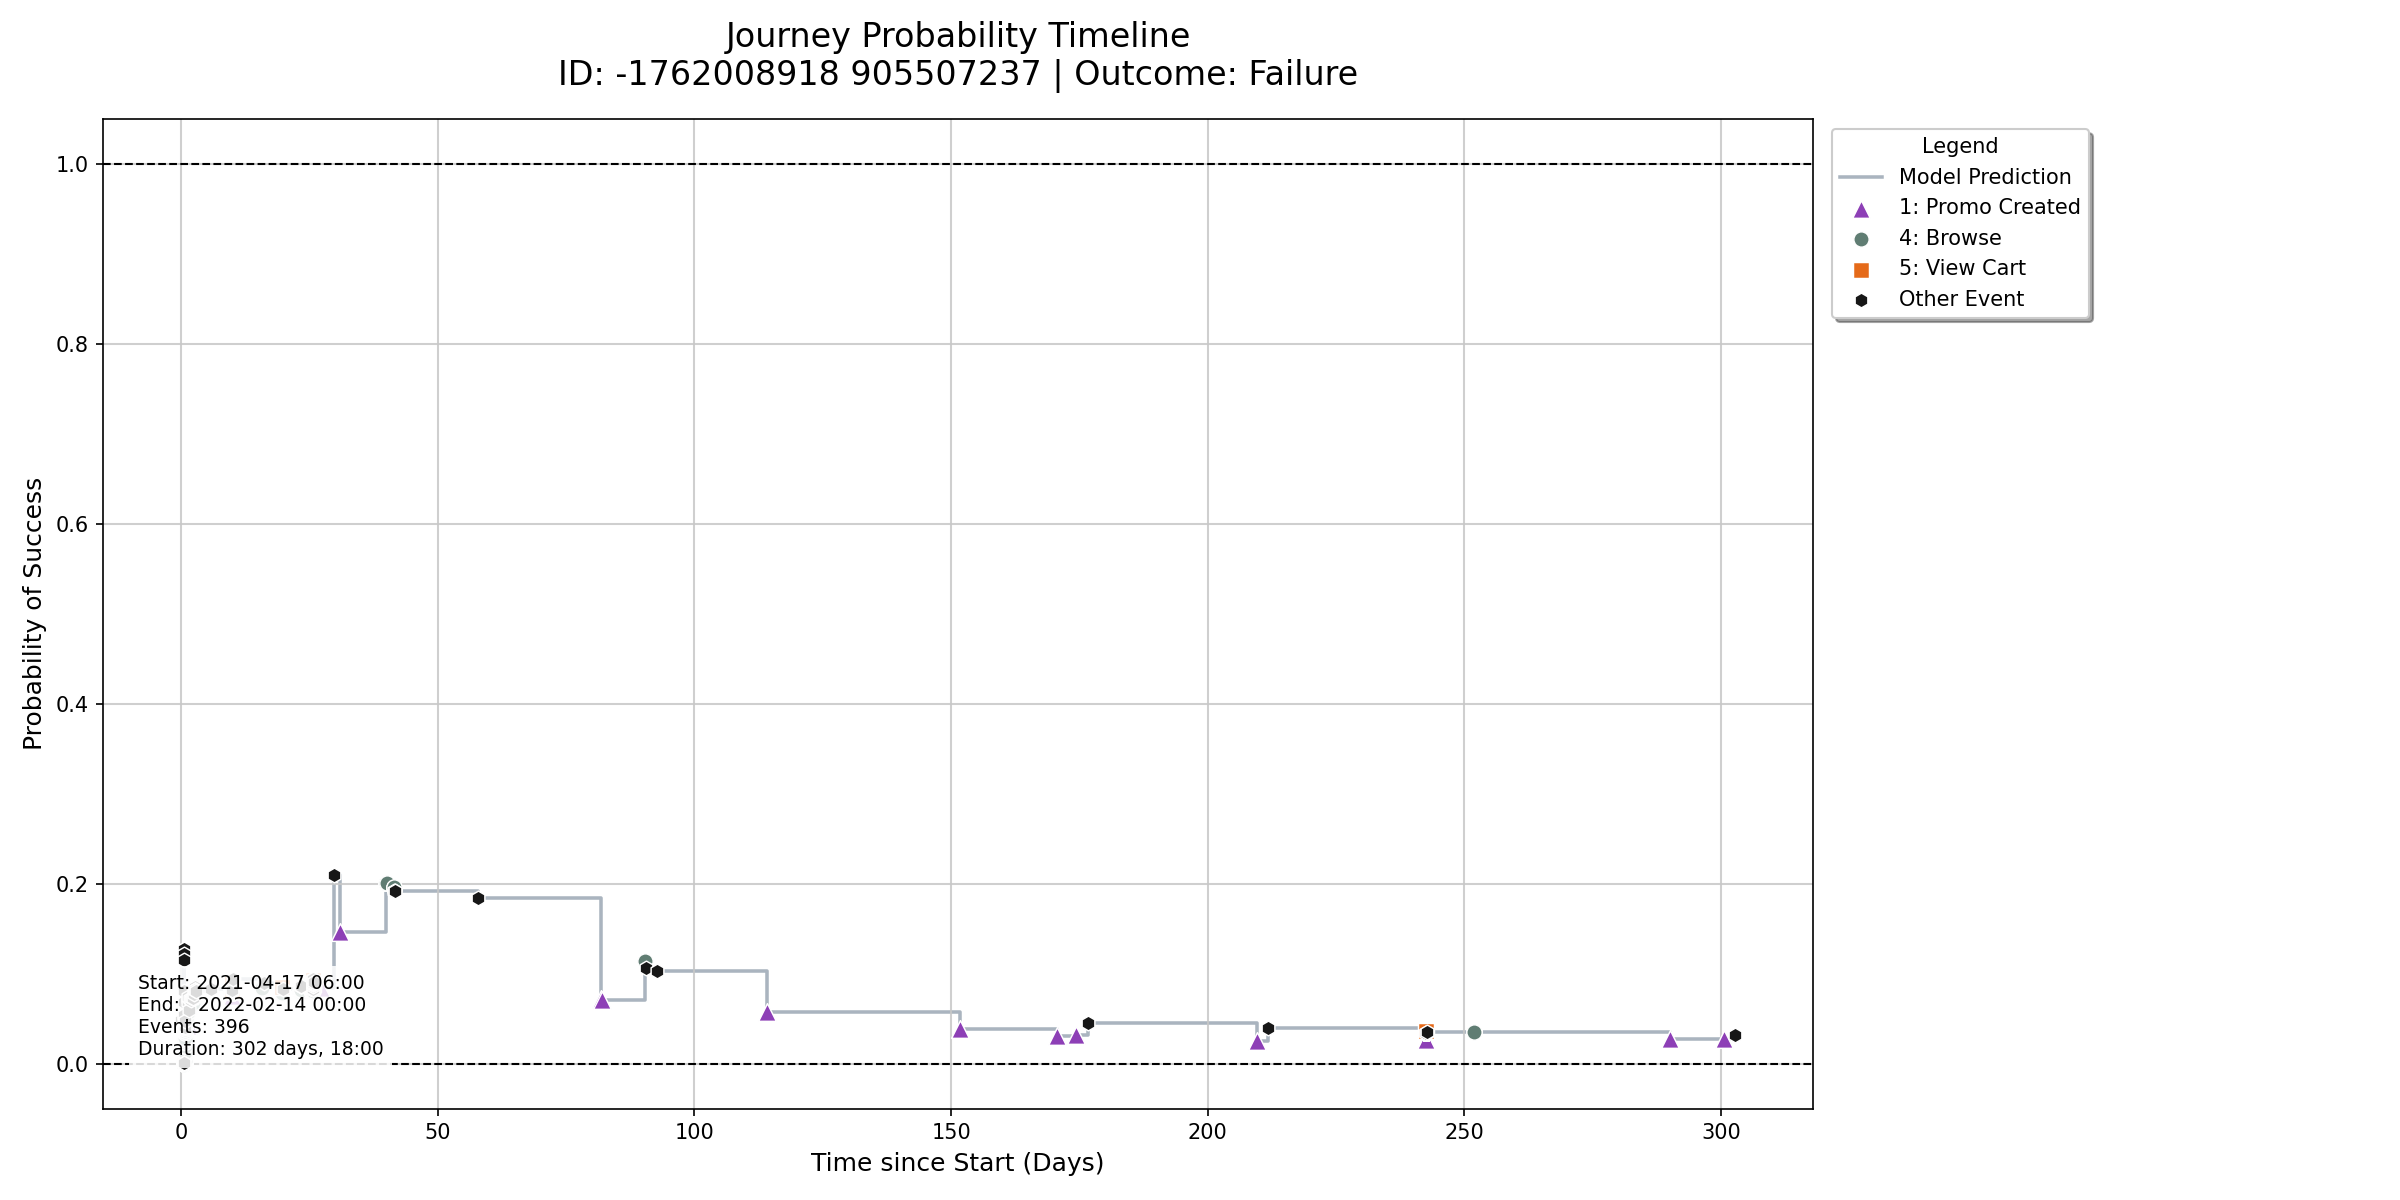

The full-view plot shows that this failed journey never becomes very likely to ship. The maximum predicted probability is about 0.209, and the probability trends back down as the journey continues without reaching deeper purchase milestones.

The zoomed plot focuses on the first 20 days, where most of the dense early user activity occurs.

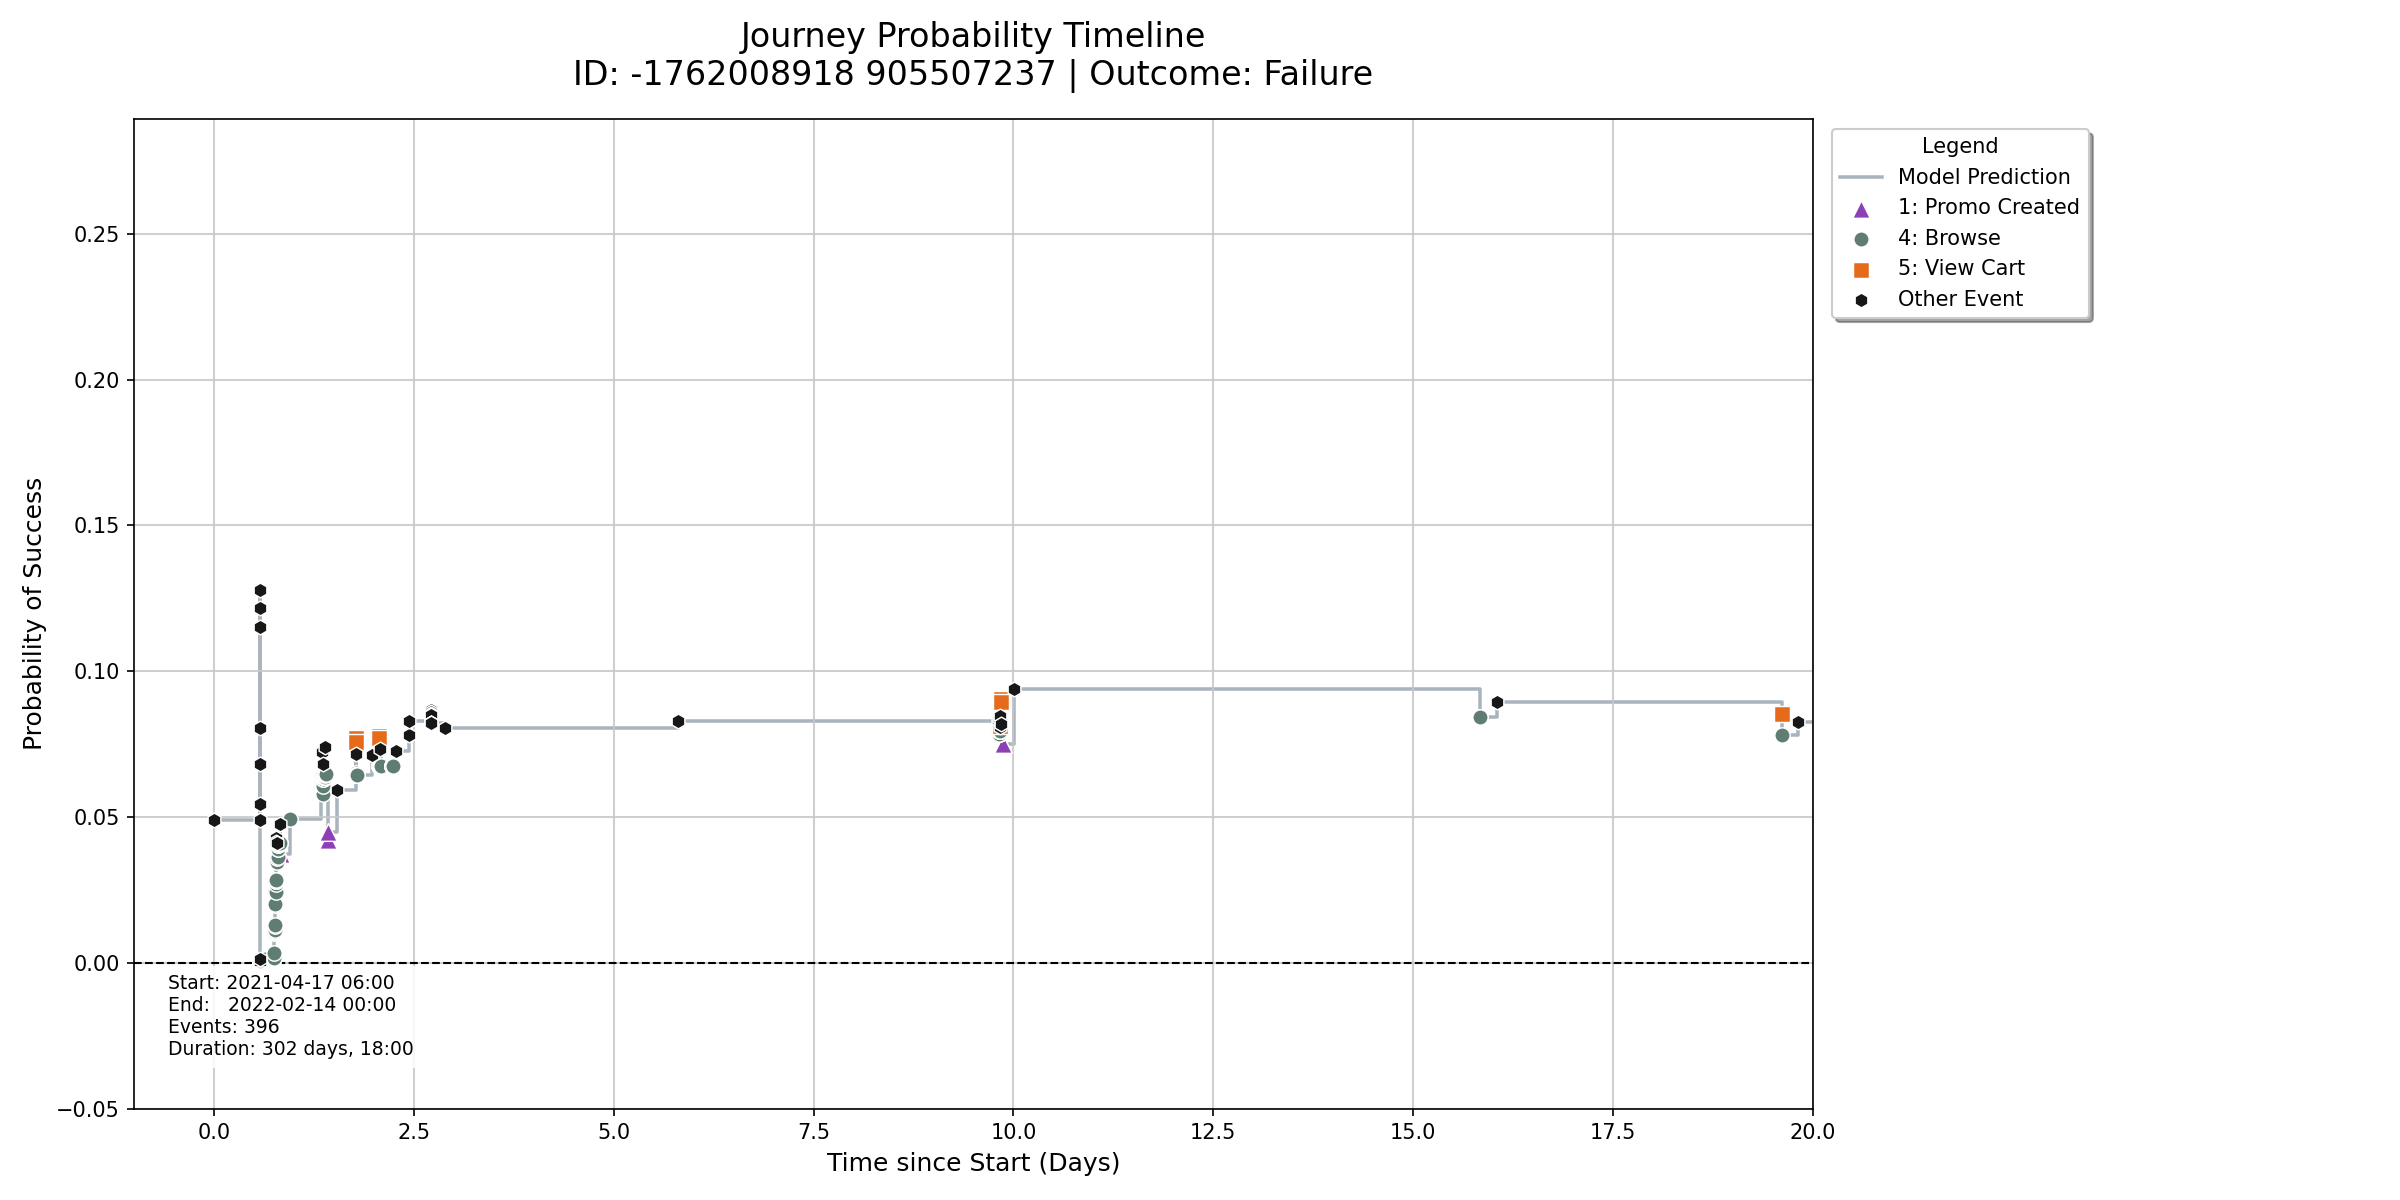

Largest absolute probability changes in this journey:

| Action # | Action                   | Time since start | Probability | Change |
| -------- | ------------------------ | ---------------- | ----------- | ------ |
| 299      | catalog_(mail)           | 29.75 days       | 0.209       | +0.125 |
| 321      | promotion_created        | 81.74 days       | 0.072       | -0.113 |
| 300      | promotion_created        | 31.04 days       | 0.146       | -0.063 |
| 4        | application_web_view     | 0.58 days        | 0.128       | +0.060 |
| 301      | browse_products          | 39.98 days       | 0.201       | +0.055 |
| 9        | application_web_approved | 0.58 days        | 0.000       | -0.054 |

Selected journey: -1762008918 905507237
OOB accuracy: 0.978


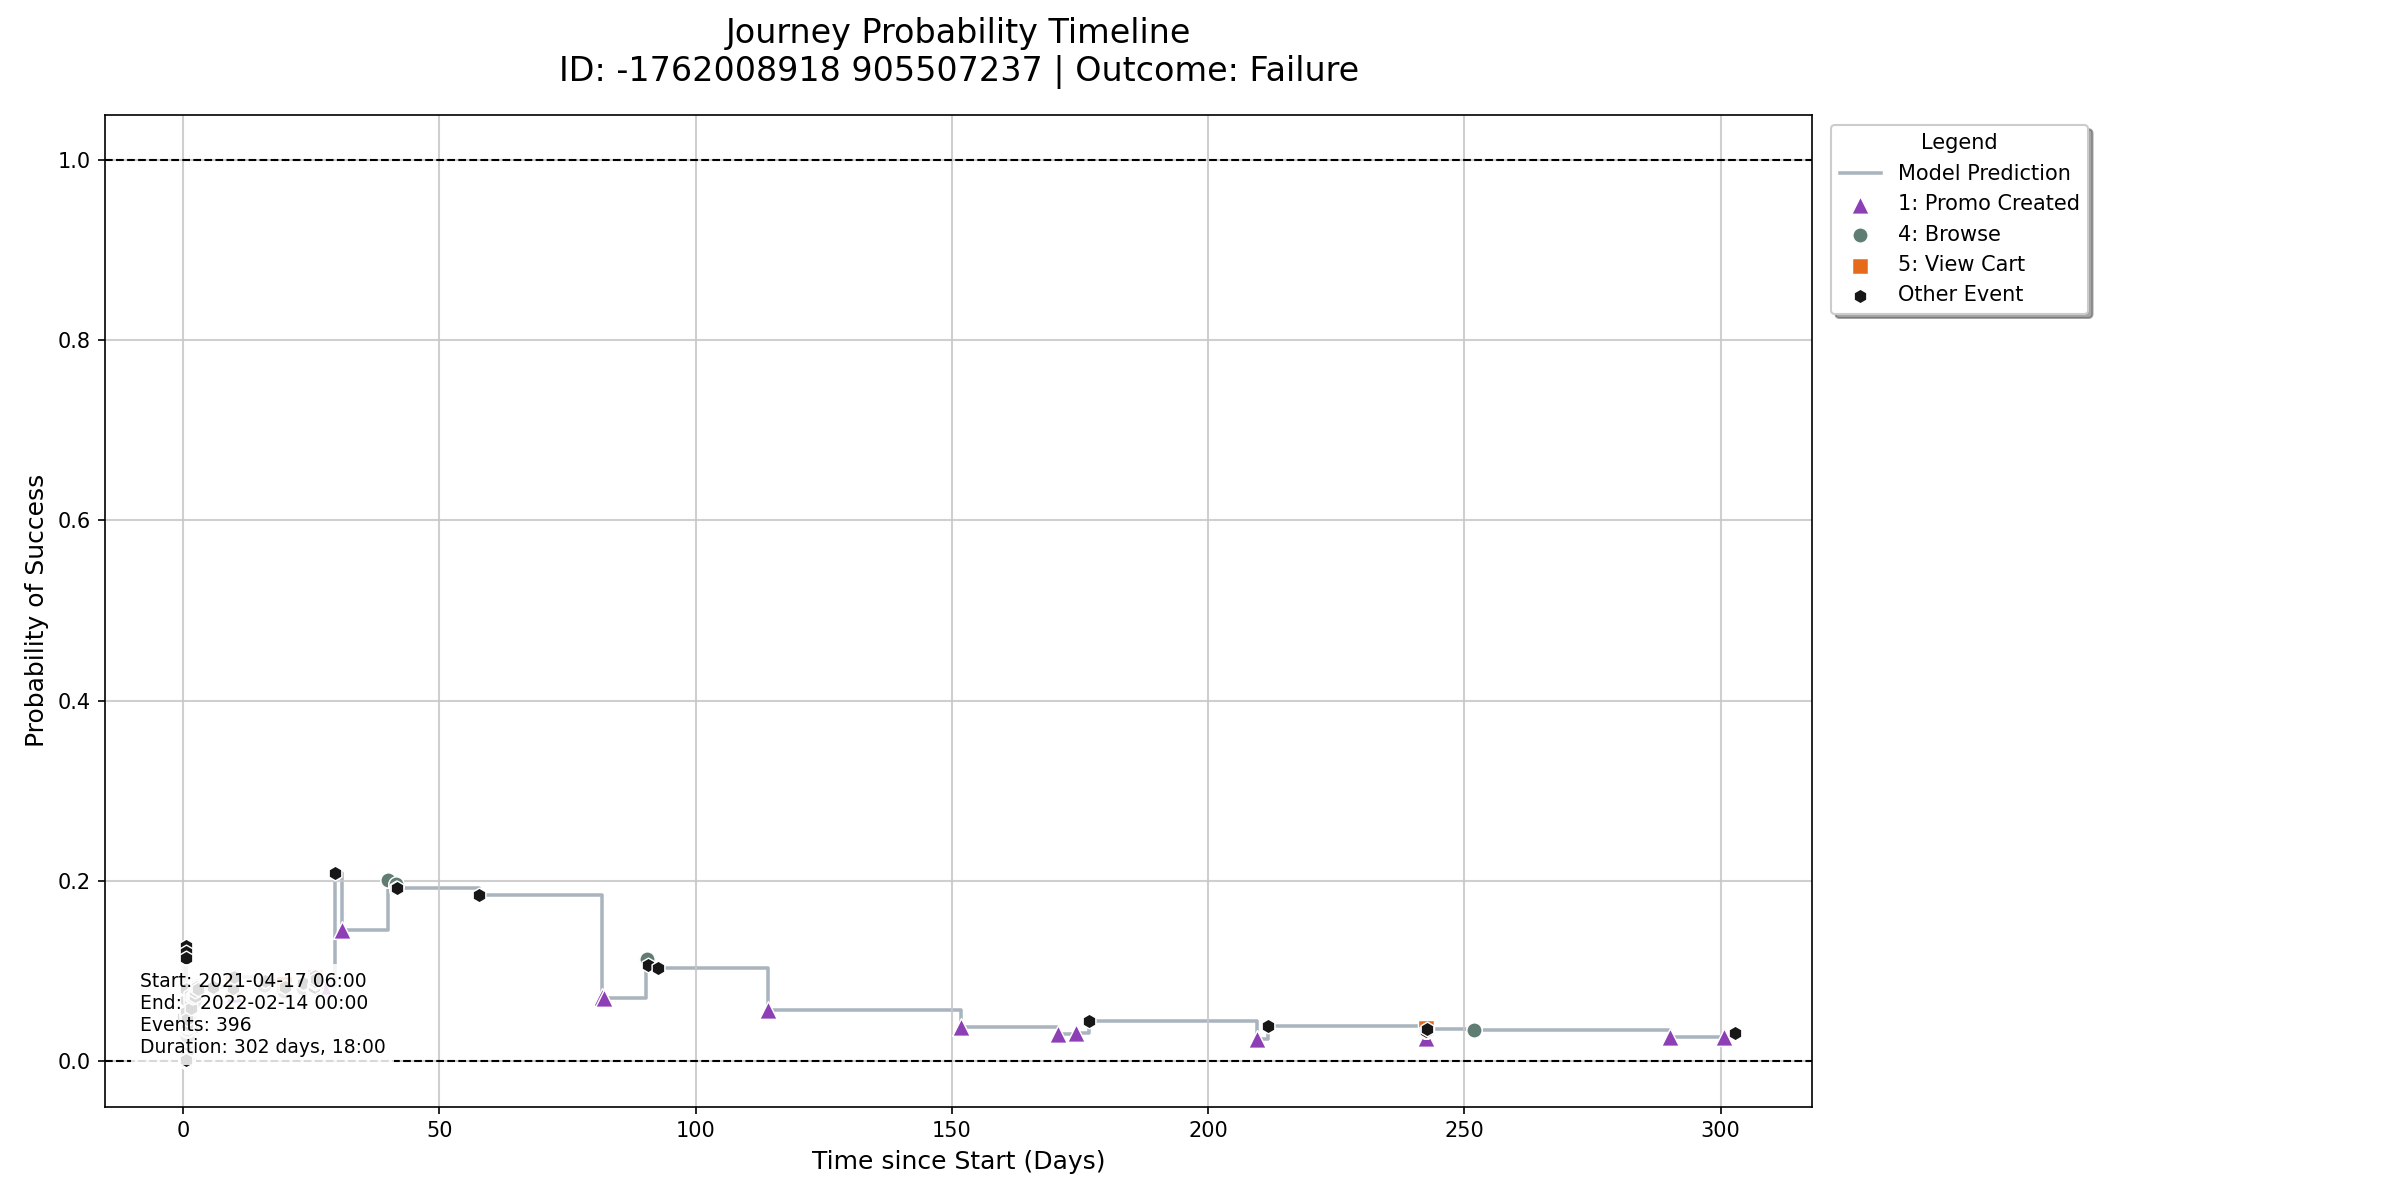

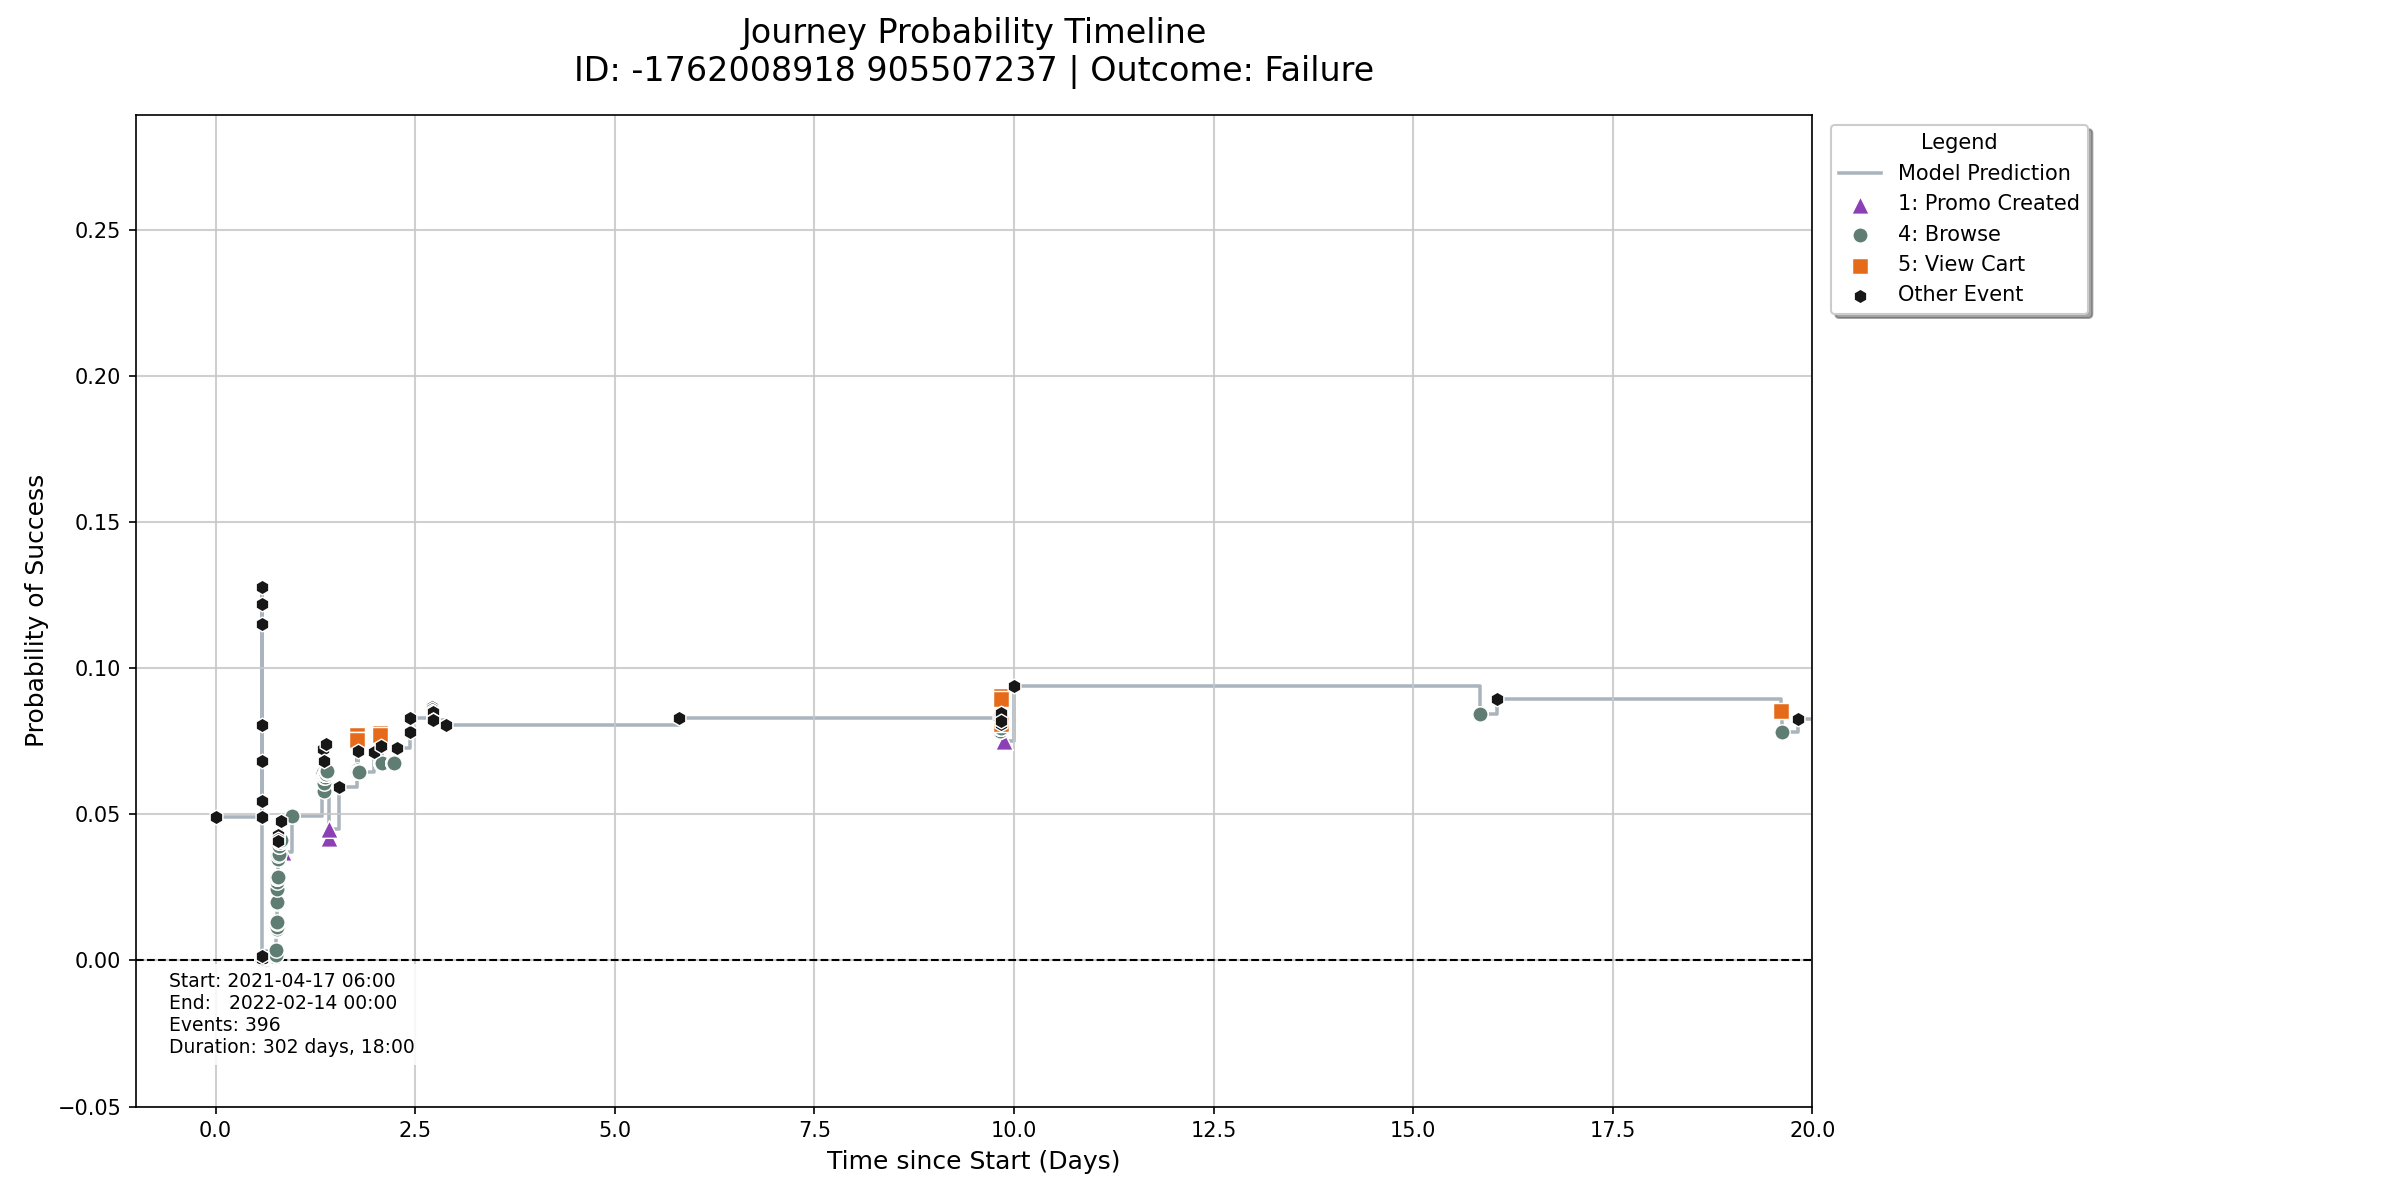

,event_number,event_name,time_since_start_days,predicted_probability,probability_delta
298,299,catalog_(mail),29.75,0.209,+0.125
320,321,promotion_created,81.74,0.072,-0.113
299,300,promotion_created,31.04,0.146,-0.063
3,4,application_web_view,0.58,0.128,+0.060
300,301,browse_products,39.98,0.201,+0.055
8,9,application_web_approved,0.58,0.000,-0.054


In [4]:
probability_timeline, probability_oob, probability_journey_id, df_sample = make_probability_timeline()
print(f"Selected journey: {probability_journey_id}")
print(f"OOB accuracy: {probability_oob:.3f}")

display(Image(filename=str(PROBABILITY_PLOT_PATH)))
display(Image(filename=str(PROBABILITY_ZOOM_PLOT_PATH)))

changes = probability_timeline.reindex(
    probability_timeline["probability_delta"].abs().sort_values(ascending=False).index
).head(6).copy()
changes["time_since_start_days"] = changes["time_since_start_days"].map(lambda x: f"{x:.2f}")
changes["predicted_probability"] = changes["predicted_probability"].map(lambda x: f"{x:.3f}")
changes["probability_delta"] = changes["probability_delta"].map(lambda x: f"{x:+.3f}")
changes[["event_number", "event_name", "time_since_start_days", "predicted_probability", "probability_delta"]]